In [1]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
%matplotlib inline

In [2]:
print(torch.cuda.is_available())
print(torch.cuda.device_count())
print(torch.cuda.get_device_name(0))

True
1
NVIDIA GeForce GTX 1650


In [14]:
device = torch.device('cuda')
device = 'cpu'

In [15]:
words = open("names.txt", "r").read().splitlines()
words[:8]

['emma', 'olivia', 'ava', 'isabella', 'sophia', 'charlotte', 'mia', 'amelia']

In [16]:
len(words)

32033

In [17]:
chars = sorted(list(set(''.join(words))))
stoi = {s:i+1 for i,s in enumerate(chars)}
stoi['.'] = 0
itos = {i:s for s,i in stoi.items()}
vocab_size = len(itos)
print(itos)
print(vocab_size)


{1: 'a', 2: 'b', 3: 'c', 4: 'd', 5: 'e', 6: 'f', 7: 'g', 8: 'h', 9: 'i', 10: 'j', 11: 'k', 12: 'l', 13: 'm', 14: 'n', 15: 'o', 16: 'p', 17: 'q', 18: 'r', 19: 's', 20: 't', 21: 'u', 22: 'v', 23: 'w', 24: 'x', 25: 'y', 26: 'z', 0: '.'}
27


In [18]:
# build the dataset
block_size = 3 #  context lengthL how many characters do we take to predict the next one

def build_dataset(words):
    X, Y = [], []
    for w in words:
        
        # print(w)
        context = [0] * block_size
        for ch in w + '.':
            ix= stoi[ch]
            X.append(context)
            Y.append(ix)
            # print(''.join(itos[i] for i in context), '---->', itos[ix])
            context = context[1:] + [ix] # crop and append
            
    X = torch.tensor(X, device=device)
    Y = torch.tensor(Y, device=device)
    print(X.shape, Y.shape)
    return X, Y

import random
random.seed(42)
random.shuffle(words)
n1 = int(0.8*len(words))
n2 = int(0.9*len(words))
Xtr, Ytr = build_dataset(words[:n1])
Xdev, Ydev = build_dataset(words[n1:n2])
Xte, Yte = build_dataset(words[n2:])

torch.Size([182625, 3]) torch.Size([182625])
torch.Size([22655, 3]) torch.Size([22655])
torch.Size([22866, 3]) torch.Size([22866])


In [ ]:
n_embed = 10
n_hidden = 200

g = torch.Generator(device=device).manual_seed(2147483647)
C = torch.randn((vocab_size,n_embed), generator=g, device=device)
w1 = torch.randn((n_embed * block_size,n_hidden), generator=g, device=device) *(5/3) /(n_embed*block_size)**.5
# b1 = torch.randn(n_hidden, generator=g, device=device) * 0.01
w2 = torch.randn((n_hidden,vocab_size), generator=g, device=device) * 0.01
b2 = torch.randn(vocab_size, generator=g, device=device) * 0

bngain = torch.ones((1, n_hidden), device=device)
bnbias = torch.ones((1, n_hidden), device=device)
bnmean_running = torch.zeros((1,n_hidden), device=device)
bnstd_running = torch.zeros((1,n_hidden), device=device)

parameters = [C, w1, b1, w2, b2, bngain, bnbias]
print(sum(p.nelement() for p in parameters))
for p in parameters:
    p.requires_grad = True

12297


In [ ]:
max_steps = 100000
batch_size = 32
lossi = []
stepi = []

for i in range(max_steps):
    
    # mininbactch construct
    ix = torch.randint(0, Xtr.shape[0], (batch_size,), generator=g, device=device)
    xb, yb = Xtr[ix], Ytr[ix]
    
    # forward pass
    emb = C[xb] # embed the characters into vectors
    embcat = emb.view(emb.shape[0], -1) # concatenate the vectors
    # Linear layer 
    hpreact = embcat @ w1 #+ b1 # hidden layer pre-activation
    # batchnorm layer
    bnmeani = hpreact.mean(0, keepdim=True)
    bnstdi = hpreact.std(0, keepdim=True)
    hpreact = bngain * (hpreact - bnmeani) / bnstdi  + bnbias# normalization
    
    with torch.no_grad():
        bnmean_running = 0.999 * bnmean_running + 0.001 * bnmeani
        bnstd_running = 0.999 * bnstd_running + 0.001 * bnstdi
    
    
    # Non-linearity
    h = torch.tanh(hpreact) # hidden layer
    logits = h @ w2 + b2 # output layer
    loss = F.cross_entropy(logits,yb)
    # print(loss.item())


    # backward pass
    for p in parameters:
        p.grad = None
    loss.backward()

    # update
    lr = 0.1 if i < 50000 else 0.01
    for p in parameters:
        p.data += -lr * p.grad
        
    if i % 10000 == 0:
        print(f'{i:7d}/{max_steps:7d}: {loss.item() :.4f}')
        
    # break
        
    stepi.append(i)
    lossi.append(loss.log10().item())
    
    # break
        
print(loss.item())

      0/ 100000: 3.2947
  10000/ 100000: 2.6618
  20000/ 100000: 1.8812
  30000/ 100000: 2.3945
  40000/ 100000: 2.0966
  50000/ 100000: 2.6715
  60000/ 100000: 2.2126
  70000/ 100000: 2.0707
  80000/ 100000: 2.0896
  90000/ 100000: 1.8307
2.8480923175811768


tensor(0.0086, device='cuda:0') tensor(1.0155, device='cuda:0')
tensor(0.0005, device='cuda:0') tensor(1.0090, device='cuda:0')


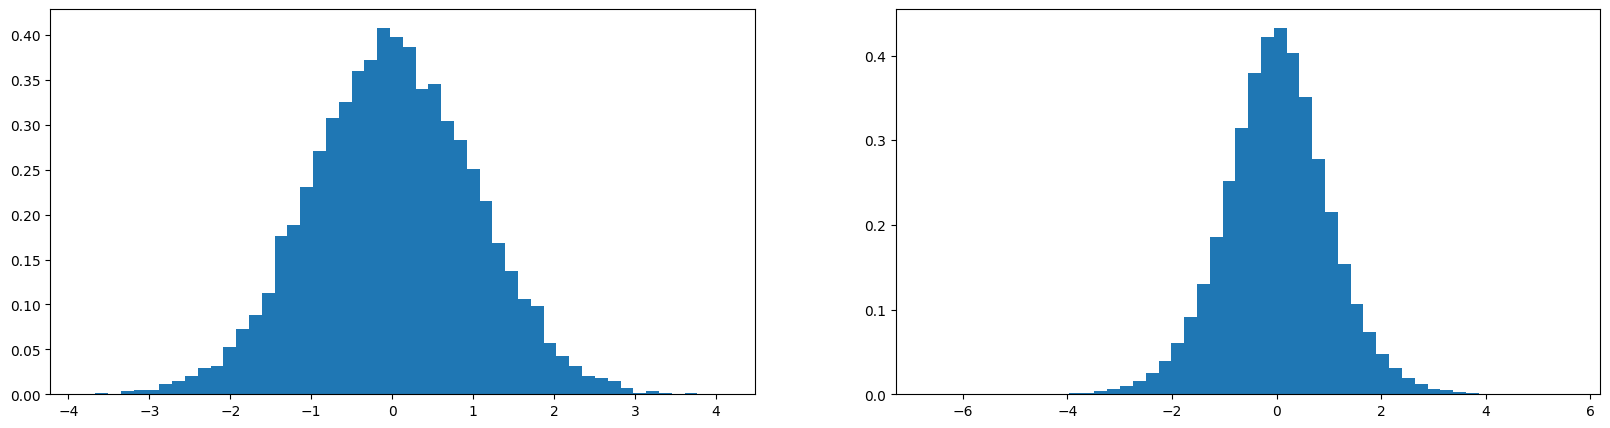

In [18]:
x = torch.randn((1000, 10), device=device)
w = torch.randn((10, 200), device=device) / 10**0.5

y = x @ w
print(x.mean(), x.std())
print(y.mean(), y.std())

plt.figure(figsize=(20,5))
plt.subplot(121)
plt.hist(x.view(-1).tolist(), 50, density=True);
plt.subplot(122)
plt.hist(y.view(-1).tolist(), 50, density=True);

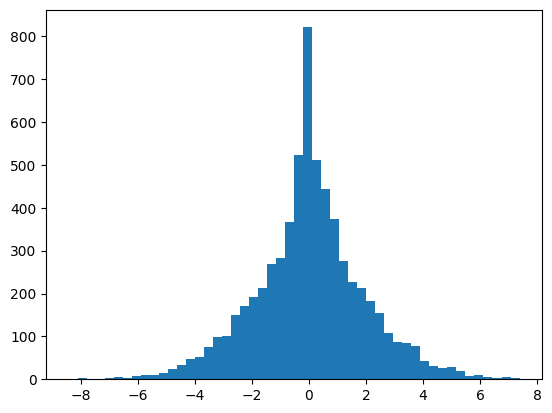

In [34]:
plt.hist(hpreact.view(-1).tolist(),50);

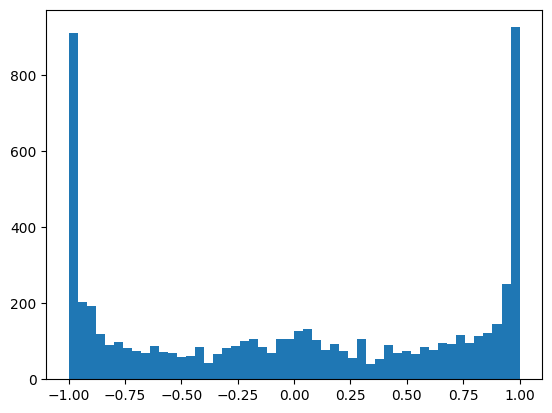

In [35]:
plt.hist(h.view(-1).tolist(),50);

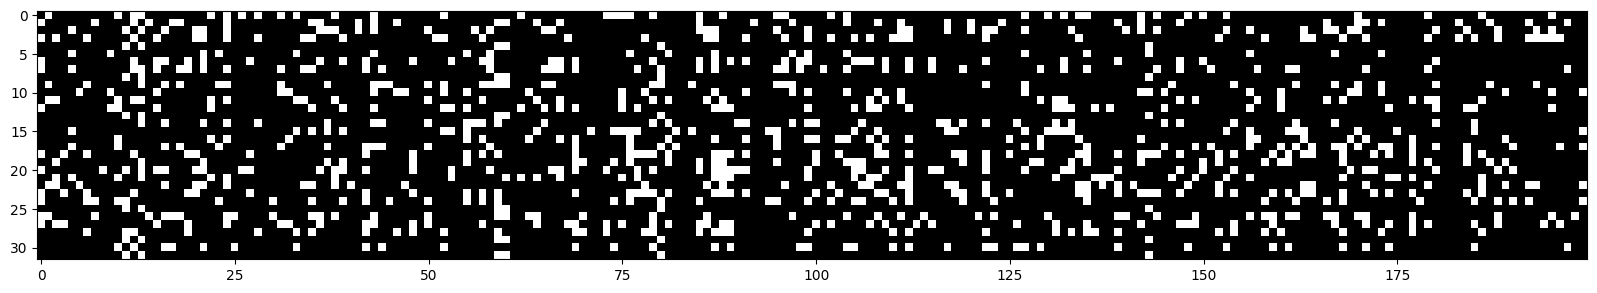

In [36]:
plt.figure(figsize=(20,10))
plt.imshow(h.detach().cpu().abs() > 0.99, cmap='gray', interpolation='nearest')

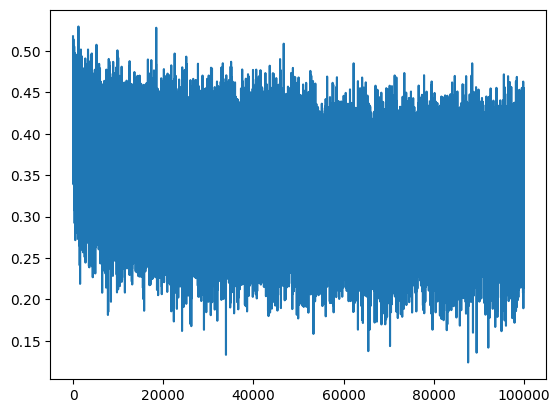

In [34]:
plt.plot(lossi)

In [35]:
# calibrate the batch norm at the end of training

with torch.no_grad():
    # pass the training set through
    emb = C[Xtr]
    embcat = emb.view(emb.shape[0], -1)
    hpreact = embcat @ w1 + b1
    
    # measure the mean/std over the entire training set
    bnmean = hpreact.mean(0, keepdim=True)
    bnstd = hpreact.std(0, keepdim=True)
    

In [40]:
@torch.no_grad()

def split_loss(split):
    x,y = {
        'train': (Xtr, Ytr),
        'val': (Xdev, Ydev),
        'test': (Xte, Yte),
    }[split]
    emb = C[x]
    embcat = emb.view(emb.shape[0], -1)
    hpreact = embcat @ w1 #+ b1
    # hpreact = bngain * (hpreact - hpreact.mean(0, keepdim=True)) / hpreact.std(0, keepdim=True)  + bnbias# normalization
    hpreact = bngain * (hpreact - bnmean_running) / bnstd_running + bnbias
    h = torch.tanh(hpreact)
    logits = h @ w2 + b2
    loss = F.cross_entropy(logits, y)
    print(split, loss.item())
    
split_loss('train')
split_loss('val')

train 2.0913209915161133
val 2.1253702640533447


In [15]:
g = torch.Generator(device=device).manual_seed(2147483647 + 10)

for _ in range(20):

    out = []
    context = [0] * block_size
    while True:
        context_tensor = torch.tensor([context], device=device)
        emb = C[context_tensor]
        h = torch.tanh(emb.view(1, -1) @ w1 + b1)
        logits = h @ w2 + b2
        probs = F.softmax(logits, dim=1)

        ix = torch.multinomial(
            probs,
            num_samples=1,
            generator=g
        ).item()

        context = context[1:] + [ix]
        out.append(ix)

        if ix == 0:
            break

    print(''.join(itos[i] for i in out))

bree.
sahemri.
deiralynn.
hardy.
cess.
fidijouur.
jheman.
jacion.
gedgy.
tain.
meth.
brelloni.
absteth.
jacedelick.
avrah.
aan.
carlana.
derickariel.
thi.
bravorson.


In [8]:
# summary -------------------------

In [45]:
class Linear:
    
    def __init__(self, fan_in, fan_out, bias=True):
        self.weight = torch.randn((fan_in, fan_out), generator=g, device=device) / fan_in**0.5
        self.bias = torch.zeros((fan_out), device=device) if bias else None
        
    def __call__(self, x):
        self.out = x @ self.weight
        if self.bias is not None:
            self.out += self.bias
        return self.out
    
    def parameters(self):
        return [self.weight] + ([] if self.bias is None else [self.bias])
    
    
class BatchNorm1d:
    
    def __init__(self, dim, eps=1e-5, momentum=0.1):
        self.eps = eps
        self.momentum = momentum
        self.training = True
        # parameters trained with backprop
        self.gamma = torch.ones((dim), device=device)
        self.beta = torch.zeros((dim), device=device)
        # buffers (trained with a running 'momentum update')
        self.running_mean = torch.zeros((dim), device=device)
        self.running_var = torch.ones((dim), device=device)
        
    def __call__(self, x):
        # calculate the forward pass
        if self.training:
            xmean = x.mean(0, keepdims=True)
            xvar = x.var(0, keepdims=True)
        else:
            xmean = self.running_mean
            xvar = self.running_var
        xhat = (x - xmean) / torch.sqrt(xvar + self.eps)
        self.out = self.gamma * xhat + self.beta
        # update buffers
        if self.training:
            with torch.no_grad():
                self.running_mean = (1-self.momentum)*self.running_mean + self.momentum * xmean
                self.running_var = (1-self.momentum)*self.running_var + self.momentum * xvar
        return self.out
    
    def parameters(self):
        return [self.gamma, self.beta]
    
class Tanh:
    def __call__(self,x):
        self.out = torch.tanh(x)
        return self.out

    def parameters(self):
        return []

In [58]:
n_embed = 10 # the dimensionality of the character embedding vectors
n_hidden = 100 # the number of neurons in the hidden layer of the MLP
block_size = 3
g = torch.Generator(device=device).manual_seed(2147483647)

C = torch.randn((vocab_size, n_embed), generator=g, device=device)
layers = [
    Linear(n_embed * block_size, n_hidden),BatchNorm1d(n_hidden), Tanh(),
    Linear(n_hidden, n_hidden), BatchNorm1d(n_hidden), Tanh(),
    Linear(n_hidden, n_hidden), BatchNorm1d(n_hidden), Tanh(),
    Linear(n_hidden, n_hidden), BatchNorm1d(n_hidden), Tanh(),
    Linear(n_hidden, n_hidden), BatchNorm1d(n_hidden), Tanh(),
    Linear(n_hidden, vocab_size),BatchNorm1d(vocab_size),
]

with torch.no_grad():
    
    # last layer make less confident
    layers[-1].gamma *=  0.1
    # all other layers: apply gain
    for layer in layers[:-1]:
        if isinstance(layer, Linear):
            layer.weight *= 5/3
        
parameters = [C] + [p for layer in layers for p in layer.parameters()]
print(sum(p.nelement() for p in parameters))
for p in parameters:
    p.requires_grad = True
    

47551


In [59]:
# optimzation

max_steps = 200000
batch_size = 32
lossi = []
ud = []

for i in range(max_steps):
    
    # minibatch construct
    ix = torch.randint(0, Xtr.shape[0], (batch_size, ), generator=g, device=device)
    Xb, Yb = Xtr[ix], Ytr[ix] # batch X, Y
    
    # forward pass
    emb = C[Xb]
    x = emb.view(emb.shape[0], -1) #concatenate the vectors
    for layer in layers:
        x = layer(x)
    loss = F.cross_entropy(x, Yb) # loss function
    
    # backward pass
    for layer in layers:
        layer.out.retain_grad() # adter debug: would take out retain graph
    for p in parameters:
         p.grad=None
    loss.backward()
    
    # update
    lr = 0.1 if 1 < 100000 else 0.01
    for p in parameters:
        p.data += -lr * p.grad
    
    # track stats
    if i % 10000 == 0:
        print(f"{i:7d}/ {max_steps:7d}: {loss.item():4f}")
    lossi.append(loss.log10().item())
    with torch.no_grad():
        ud.append([(lr*p.grad.std() / p.data.std()).log10().item() for p in parameters])
    
    if i >1000:
        break

      0/  200000: 3.287031


layer  2 (Tanh) | mean -0.0019 | std 0.6316 | saturated 2.97%
layer  5 (Tanh) | mean +0.0056 | std 0.6440 | saturated 2.41%
layer  8 (Tanh) | mean -0.0033 | std 0.6423 | saturated 2.44%
layer 11 (Tanh) | mean +0.0016 | std 0.6435 | saturated 2.22%
layer 14 (Tanh) | mean -0.0042 | std 0.6442 | saturated 2.25%


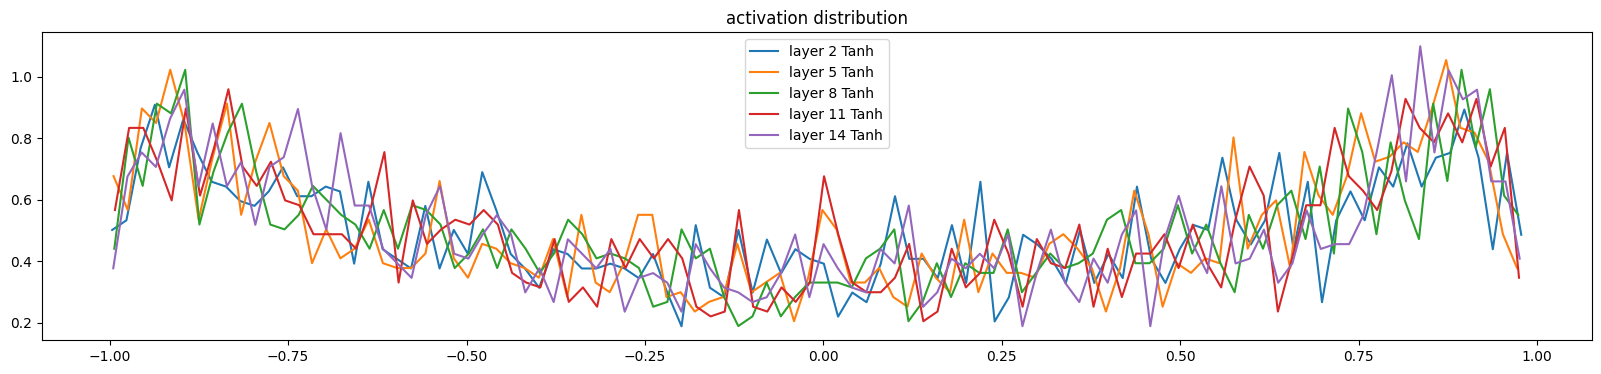

In [60]:
plt.figure(figsize=(20,4))
legends = []

for i, layer in enumerate(layers[:-1]):
    if isinstance(layer, Tanh):

        t = layer.out.detach()

        print(
            f'layer {i:2d} ({layer.__class__.__name__}) | '
            f'mean {t.mean():+.4f} | '
            f'std {t.std():.4f} | '
            f'saturated {(t.abs() > 0.97).float().mean()*100:.2f}%'
        )

        t_cpu = t.cpu()

        hy, hx = torch.histogram(t_cpu, density=True)

        plt.plot(hx[:-1], hy)
        legends.append(f'layer {i} Tanh')

plt.legend(legends)
plt.title('activation distribution')
plt.show()

layer 2 (      Tanh): mean -0.000000, std 3.561996e-03
layer 5 (      Tanh): mean +0.000000, std 3.119536e-03
layer 8 (      Tanh): mean +0.000000, std 2.904413e-03
layer 11 (      Tanh): mean +0.000000, std 2.580228e-03
layer 14 (      Tanh): mean -0.000000, std 2.440871e-03


Text(0.5, 1.0, 'gradient distribution')

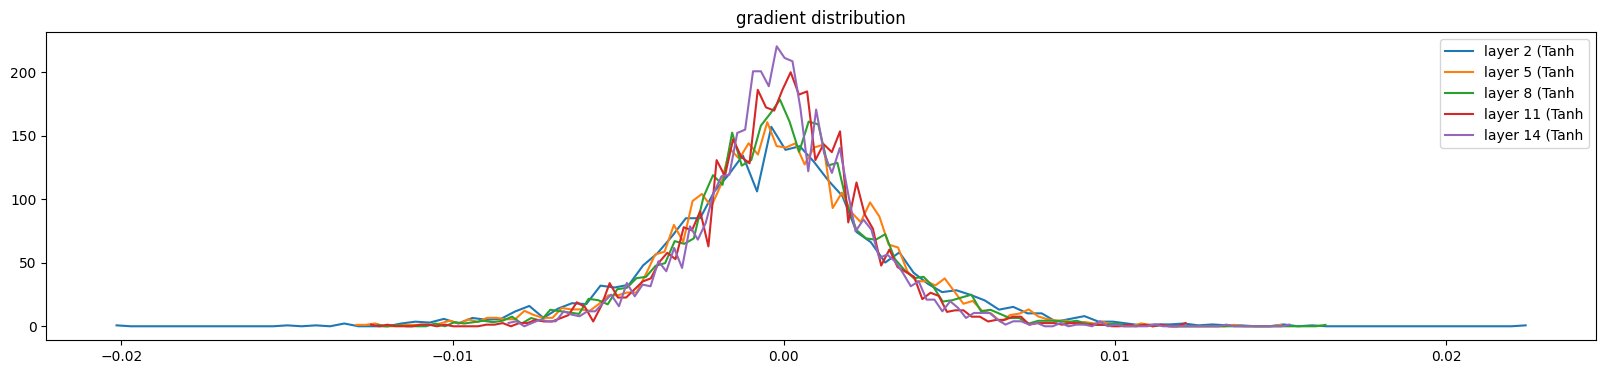

In [61]:
# visualize histograms
plt.figure(figsize=(20, 4)) # width and height of the plot
legends = []
for i, layer in enumerate(layers[:-1]): # note: exclude the output layer
  if isinstance(layer, Tanh):
    t = layer.out.grad.detach()
    print('layer %d (%10s): mean %+f, std %e' % (i, layer.__class__.__name__, t.mean(), t.std()))
    
    t_cpu = t.cpu()
    hy, hx = torch.histogram(t_cpu, density=True)
    plt.plot(hx[:-1].detach(), hy.detach())
    legends.append(f'layer {i} ({layer.__class__.__name__}')
plt.legend(legends);
plt.title('gradient distribution')



weight   (27, 10) | mean +0.000000 | std 8.198678e-03 | grad:data ratio 8.190319e-03
weight  (30, 100) | mean -0.000195 | std 7.650417e-03 | grad:data ratio 2.447704e-02
weight (100, 100) | mean -0.000097 | std 6.207591e-03 | grad:data ratio 3.712887e-02
weight (100, 100) | mean +0.000015 | std 5.561927e-03 | grad:data ratio 3.297634e-02
weight (100, 100) | mean +0.000008 | std 5.220611e-03 | grad:data ratio 3.110157e-02
weight (100, 100) | mean +0.000029 | std 4.829171e-03 | grad:data ratio 2.876375e-02
weight  (100, 27) | mean -0.000014 | std 9.281230e-03 | grad:data ratio 5.568826e-02


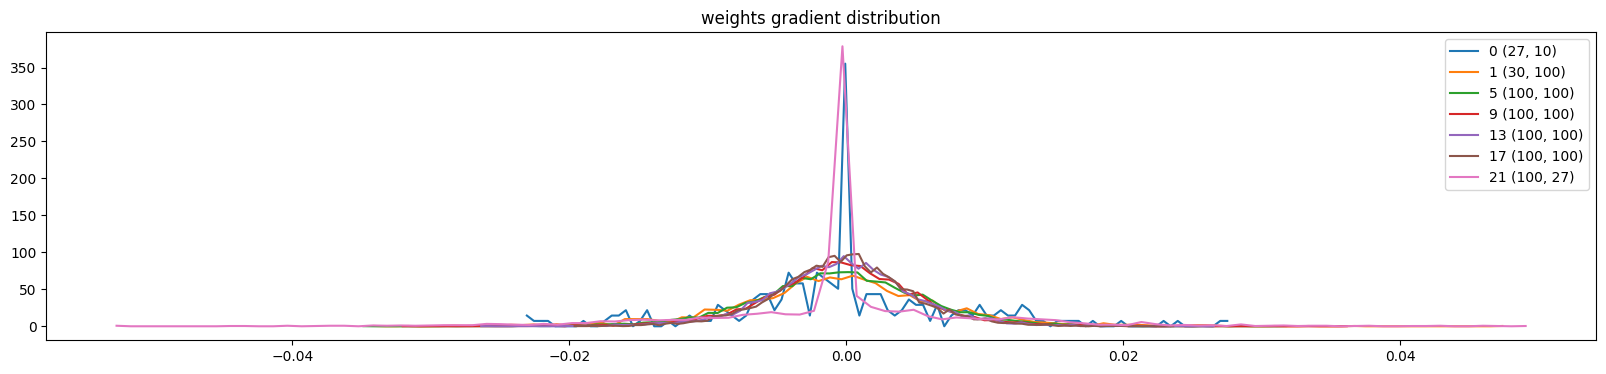

In [62]:
# visualize histograms
plt.figure(figsize=(20, 4)) # width and height of the plot
legends = []
for i,p in enumerate(parameters):
  t = p.grad
  if p.ndim == 2:
    print('weight %10s | mean %+f | std %e | grad:data ratio %e' % (tuple(p.shape), t.mean(), t.std(), t.std() / p.std()))
    hy, hx = torch.histogram(t, density=True)
    plt.plot(hx[:-1].detach(), hy.detach())
    legends.append(f'{i} {tuple(p.shape)}')
plt.legend(legends)
plt.title('weights gradient distribution');



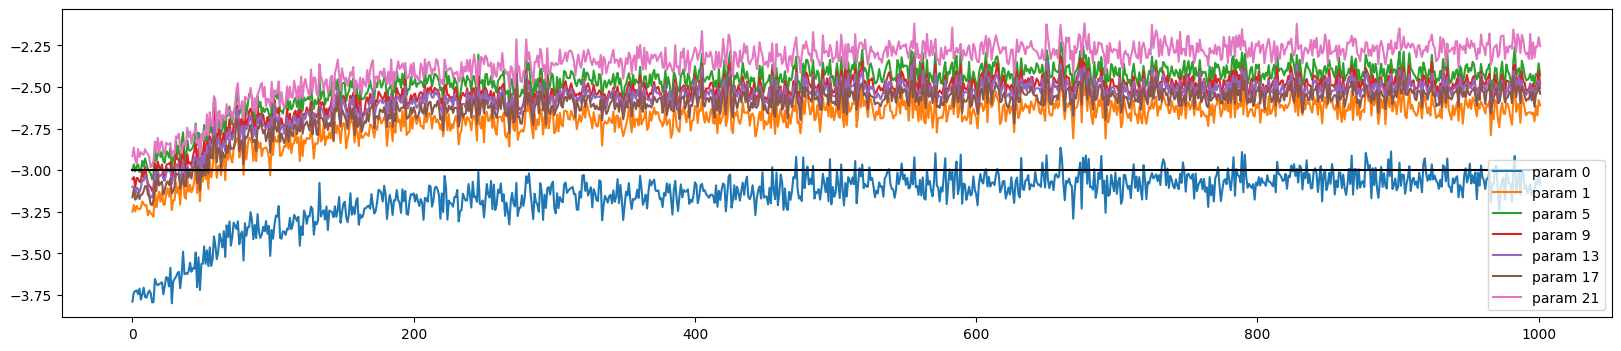

In [63]:
plt.figure(figsize=(20, 4))
legends = []
for i,p in enumerate(parameters):
  if p.ndim == 2:
    plt.plot([ud[j][i] for j in range(len(ud))])
    legends.append('param %d' % i)
plt.plot([0, len(ud)], [-3, -3], 'k') # these ratios should be ~1e-3, indicate on plot
plt.legend(legends);

